In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.tools as tools
import plotly.graph_objects as go

import ast

In [2]:
%run helpers.ipynb

In [3]:
oscar_with_imdb, imdb_non_oscar = read_data('oscar_with_imdb.csv', 'imdb_non_oscar.csv')

oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row == True else 'Nominated')
imdb_non_oscar['Status'] = 'No nomination'

In [4]:
columns = ['title', 'rating', 'meta_score', 'votes', 'languages', 'Status']

oscars_df = oscar_with_imdb[columns]
imdb_df = imdb_non_oscar[columns]

graph_df = pd.concat([oscars_df[columns], imdb_df[columns]], axis=0)

In [5]:
graph_df.head()

,title,rating,meta_score,votes,languages,Status
0,The Noose,6.5,NaN,93.0,"['None', 'English']",Nominated
1,The Patent Leather Kid,6.0,NaN,623.0,"['None', 'English']",Nominated
2,The Last Command,7.9,NaN,4800.0,"['None', 'English']",Winner
3,The Way of All Flesh,6.6,NaN,241.0,"['None', 'English']",Winner
4,A Ship Comes In,5.5,NaN,246.0,['None'],Nominated


In [6]:
graph_df.dropna(subset=['languages'], inplace=True)

In [7]:
%run helpers.ipynb

In [8]:
graph_df['language'] = graph_df['languages'].apply(lambda x: get_languages(x))
graph_df = graph_df[graph_df['language'] != '']
filtered = graph_df[~graph_df['language'].isin(['English', 'None'])] # Ceck for lowercase, so far all are capitalized

In [9]:
print(len(graph_df))
# Non English movies
len(filtered)

63698


20657

In [10]:
topn = 10
most_frequent_langs = (
    filtered['language']
    .value_counts()
    .nlargest(topn)
    .index
)

top_10_df = filtered[filtered['language'].isin(most_frequent_langs)]

top_10_grouped = top_10_df.groupby(['language', 'Status']).agg(
    avg_rating=('rating', 'mean'),
    sum_votes=('votes', 'sum'),
    total_films=('language', 'size')
).reset_index()

In [11]:
top_10_grouped

,language,Status,avg_rating,sum_votes,total_films
0,Cantonese,No nomination,6.364667,2767840.0,450
1,Cantonese,Nominated,6.800000,24000.0,1
2,French,No nomination,6.353665,13060855.0,3315
3,French,Nominated,7.401399,8857812.0,143
4,French,Winner,7.391667,780991.0,24
5,German,No nomination,6.144858,3948897.0,1799
6,German,Nominated,7.557500,4238337.0,40
7,German,Winner,7.550000,1875434.0,12
8,Hindi,No nomination,6.414255,13700551.0,1838
9,Hindi,Nominated,7.700000,226000.0,5


In [12]:
# top_10_grouped['avg_rating'] = top_10_grouped['avg_rating'].map(lambda x: f'{x:.1f}')
top_10_grouped['avg_rating_rounded'] = top_10_grouped['avg_rating'].map(lambda x: f"{x:.1f}")

# top_10_grouped['sum_votes'] = top_10_grouped['sum_votes'].map('{:,}'.format)
# top_10_grouped['total_films'] = top_10_grouped['total_films'].map(lambda x: f'{x:.,d}')

In [13]:
top_10_grouped['sum_votes'] = top_10_grouped['sum_votes'].astype(int)
top_10_grouped['sum_votes_str'] = top_10_grouped['sum_votes'].map(lambda  x: f'{x:,d}')
# top_10_grouped['total_films'] = top_10_grouped['total_films'].map(lambda x: f'{x:,d}')

In [14]:
top_10_grouped

,language,Status,avg_rating,sum_votes,total_films,avg_rating_rounded,sum_votes_str
0,Cantonese,No nomination,6.364667,2767840,450,6.4,"2,767,840"
1,Cantonese,Nominated,6.800000,24000,1,6.8,"24,000"
2,French,No nomination,6.353665,13060855,3315,6.4,"13,060,855"
3,French,Nominated,7.401399,8857812,143,7.4,"8,857,812"
4,French,Winner,7.391667,780991,24,7.4,"780,991"
5,German,No nomination,6.144858,3948897,1799,6.1,"3,948,897"
6,German,Nominated,7.557500,4238337,40,7.6,"4,238,337"
7,German,Winner,7.550000,1875434,12,7.5,"1,875,434"
8,Hindi,No nomination,6.414255,13700551,1838,6.4,"13,700,551"
9,Hindi,Nominated,7.700000,226000,5,7.7,"226,000"


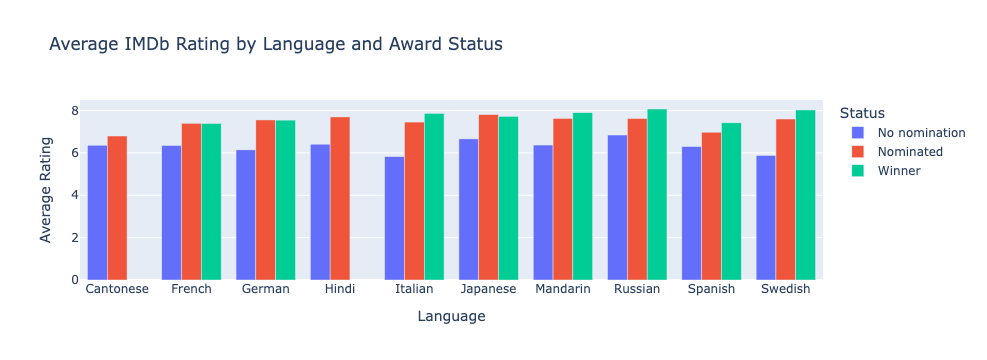

In [15]:
fig_avg = px.bar(
    top_10_grouped,
    x='language',
    y='avg_rating',
    color='Status',
    barmode='group',
    labels={'language':'Language', 'avg_rating': 'Average Rating'},
    title='Average IMDb Rating by Language and Award Status'
)

fig_avg.update_traces(hovertemplate='%{y:.1f}')
# fig_avg.update_yaxes(tickformat='d', title='Average Rating')
fig_avg.show()

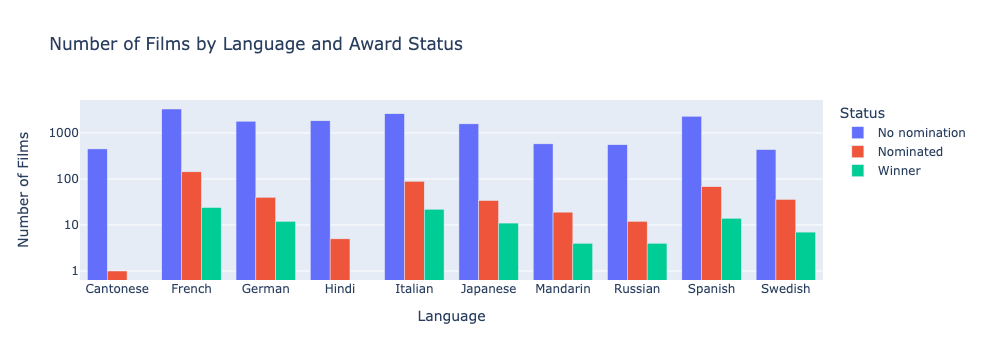

In [16]:
fig_count = px.bar(
    top_10_grouped,
    x='language',
    y='total_films',
    color='Status',
    barmode='group',
    labels={'language':'Language', 'total_filmes': 'Number of Films'},
    title='Number of Films by Language and Award Status'
)

fig_count.update_traces(hovertemplate='%{y:,d}<extra></extra>')
fig_count.update_yaxes(type='log', title='Number of Films')
fig_count.show()

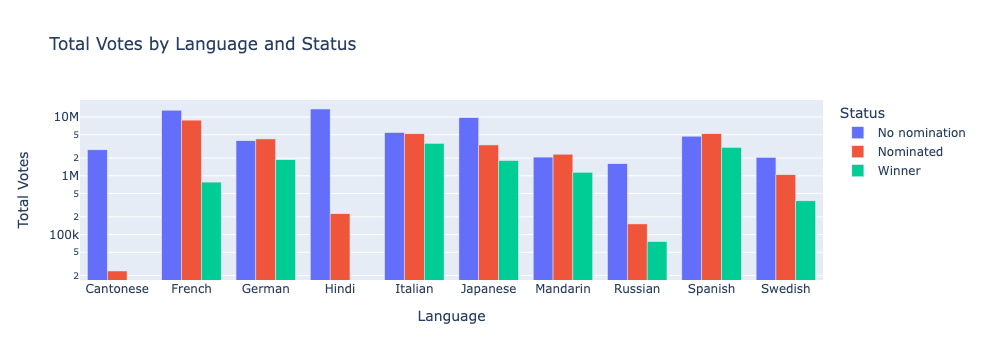

In [17]:
fig_votes = px.bar(
    top_10_grouped,
    x='language',
    y='sum_votes',
    color='Status',
    barmode='group',
    labels={'language':'Language', 'sum_votes': 'Total Votes'},
    title='Total Votes by Language and Status',
)

fig_votes.update_traces(hovertemplate='%{y:,d}')
fig_votes.update_yaxes(type='log', title='Total Votes')
# fig_votes.xlabel('Label')
fig_votes.show()
